In [18]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
import re
import matplotlib.colors as mcolors

tactic_abbr_full = {
    "ttbp":"together_traverse_best_permutation",
    "dor":"divide_over_risks",
    "rndm":"random_walk",
    "hs":"horizontal_scan_traversal",
    "phs":"partitioned_horizontal_scan_traversal",
    "sp": "spiral_traversal_swarm",
    "lb": "lidbetter",
    "toq": "traverse_ordered_qa",
    "tpq":"traverse_p_qa",
    "dd":"discounted_distance",
    "ddr":"discounted_distance_reverse",
}



SUMMARY_FILENAME = '../data/dataset/sim_results_dataset.csv'

FIXED_HIDING_STRATEGY = 'greedy'
FIXED_NUMBER_OF_HIDERS = 2

FIXED_HIDING_CANDIDATES = 5
FIXED_GRID_WIDTH = 20
FIXED_NUMBER_OF_RUNS = 100000

results = {}

In [19]:
df_all = pd.read_csv(SUMMARY_FILENAME)


In [20]:
df_filtered = df_all[
    (df_all['hide_strategy'] == FIXED_HIDING_STRATEGY) &
    (df_all['n_hiders'] == FIXED_NUMBER_OF_HIDERS) &
    (df_all['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
    (df_all['grid_width'] == FIXED_GRID_WIDTH) &
    (df_all['runs'] == FIXED_NUMBER_OF_RUNS)
]

all_swarm_sizes = sorted(df_filtered['swarm_size'].unique())

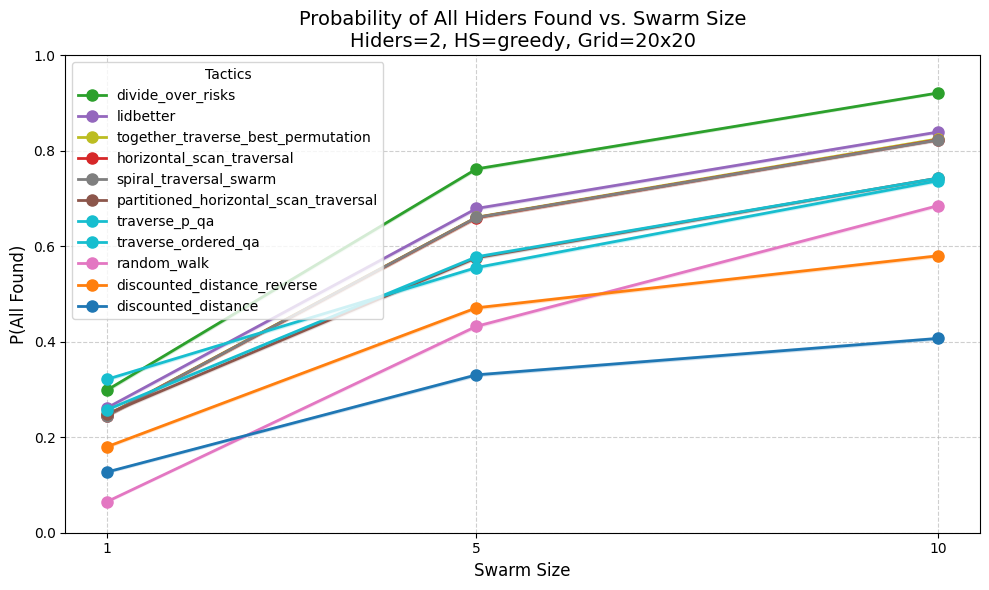

[('divide_over_risks', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.29863, 0.76208, 0.92131]), 'low': array([0.29579434, 0.75942827, 0.91962393]), 'high': array([0.30147735, 0.76471652, 0.92297159])}), ('lidbetter', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.26144, 0.67918, 0.8395 ]), 'low': array([0.25871845, 0.67627668, 0.83721008]), 'high': array([0.26417539, 0.68207292, 0.84177021])}), ('together_traverse_best_permutation', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.24602, 0.6608 , 0.82506]), 'low': array([0.243353  , 0.65785602, 0.82269088]), 'high': array([0.24870174, 0.66373465, 0.82741025])}), ('horizontal_scan_traversal', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.24523, 0.65999, 0.82323]), 'low': array([0.24256591, 0.65704435, 0.82085128]), 'high': array([0.24790887, 0.66292637, 0.82558996])}), ('spiral_traversal_swarm', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.24513, 0.66032, 0.82269]), 'low': array([0.24246628, 0.65737503, 0.82030846]

In [21]:
for tactic_name in df_filtered['tactic'].unique():

    df_tactic = df_filtered[df_filtered['tactic'] == tactic_name]

    df_tactic = df_tactic.sort_values(by='swarm_size')

    results[tactic_name] = {
        'swarm_sizes': df_tactic['swarm_size'].values,
        'P':           df_tactic['all_found_mean'].values,
        'low':         df_tactic['all_found_ci_lower'].values,
        'high':        df_tactic['all_found_ci_upper'].values
    }

all_tactic_names = sorted(tactic_abbr_full.values())
colors_list = plt.cm.tab10(np.linspace(0, 1, len(all_tactic_names)))
tactic_colors = {tactic: color for tactic, color in zip(all_tactic_names, colors_list)}


sorted_results = sorted(
    results.items(),
    key=lambda item: item[1]['P'][-1] if len(item[1]['P']) > 0 else -1,
    reverse=True  # Highest P value first
)

plt.figure(figsize=(10, 6))
ax = plt.gca()


for i, (tactic_name, data) in enumerate(sorted_results):
    if not len(data['swarm_sizes']):
        print(f"{tactic_name} no data points")
        continue

    color = tactic_colors[tactic_name]

    ax.plot(
        data['swarm_sizes'],
        data['P'],
        label=tactic_name,
        color=color,
        linewidth=2,
        marker='o',
        markersize=8
    )


    ax.fill_between(
        data['swarm_sizes'],
        data['low'],
        data['high'],
        alpha=0.15,
        color=color,
        label=f'_{tactic_name}_CI' # Underscore hides from legend
    )

ax.set_xlabel('Swarm Size', fontsize=12)
ax.set_ylabel('P(All Found)', fontsize=12)
title = (
    f'Probability of All Hiders Found vs. Swarm Size\n'
    f'Hiders={FIXED_NUMBER_OF_HIDERS}, HS={FIXED_HIDING_STRATEGY}, '
    f'Grid={FIXED_GRID_WIDTH}x{FIXED_GRID_WIDTH}'
)
ax.set_title(title, fontsize=14)

ax.legend(loc='upper left', title='Tactics')

ax.set_ylim(0, 1)

ax.set_xticks(all_swarm_sizes)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

save_filename = (
    f'prob_all_found_vs_SwarmSize_'
    f'HS{FIXED_HIDING_STRATEGY}_H{FIXED_NUMBER_OF_HIDERS}.png'
)
# plt.savefig(save_filename)
# print(f"\nPlot saved to: {save_filename}")
plt.show()

print(sorted_results)
print(data['swarm_sizes'])

Saved: swarm_tactics_heatmap.png and swarm_tactics_heatmap.pdf


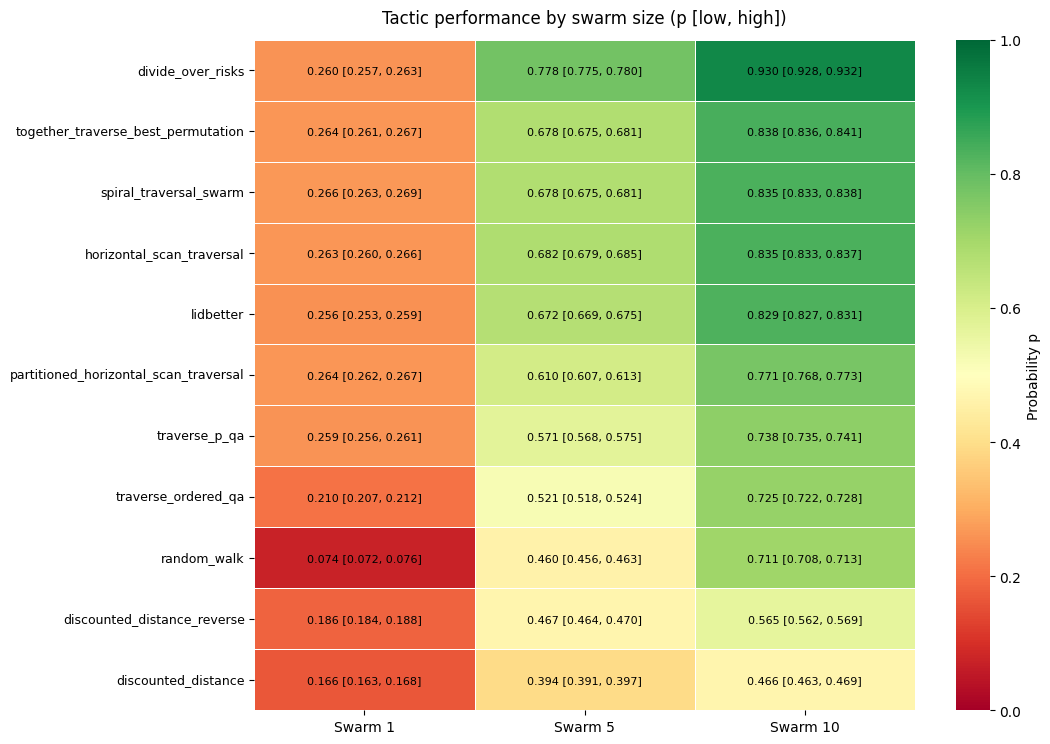

In [10]:
FIXED_SWARM_SIZE = 10

T_MIN = 0
T_MAX = 1000
T_STEP = 10
T_values = np.arange(T_MIN, T_MAX + T_STEP, T_STEP)
SIMLOGS = "../data/sim_logs/"

In [11]:
filename_pattern = re.compile(
    r"T-(.+)"                  # Group 1: TACTIC
    r"-W-(\d+)"                # Group 2: GRIDWIDTH
    r"-HS-(.+)"                # Group 3: HidingStrategy
    r"-D-(\d+)"                # Group 4: Swarmsize
    r"-C-(\d+)"                # Group 5: HidingCandidates
    r"-H-(\d+)"                # Group 6: NumberOfHiders
    r"-RUNS-(\d+)\.csv"        # Group 7: NumberOfRuns
)
results = {}
tactic_files_found = []

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:94: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Janvg\AppData\Local\Temp\ipykernel_33032\3317836312.py:25: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(SIMLOGS+filename, header=0, sep='\s+')
C:\Users\Janvg\AppData\Local\Temp\ipykernel_33032\3317836312.py:94: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('P(All Found | steps $\leq$ T)', fontsize=12)


Plot saved to: prob_all_found_vs_T_D10_HSgreedy.png


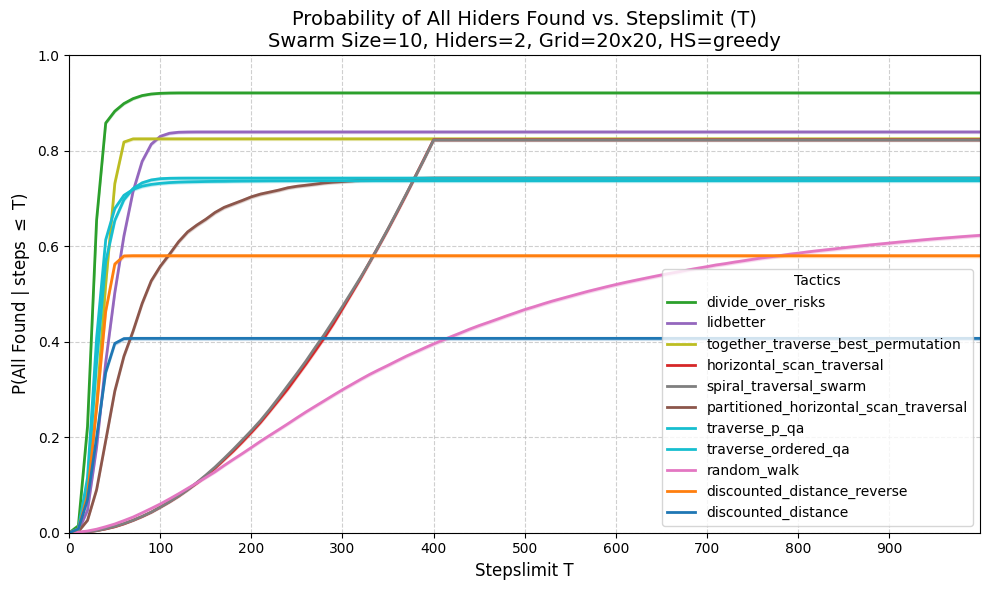

In [12]:
for filename in os.listdir(SIMLOGS):
    if not filename.endswith('.csv'):
        continue

    match = filename_pattern.match(filename)
    if not match:
        continue
    tactic = match.group(1)
    width = int(match.group(2))
    hs = match.group(3)
    swarm = int(match.group(4))
    candidates = int(match.group(5))
    hiders = int(match.group(6))
    runs = int(match.group(7))

    if (swarm == FIXED_SWARM_SIZE and
        hs == FIXED_HIDING_STRATEGY and
        candidates == FIXED_HIDING_CANDIDATES and
        hiders == FIXED_NUMBER_OF_HIDERS and
        width == FIXED_GRID_WIDTH and
        runs == FIXED_NUMBER_OF_RUNS):
        
        tactic_files_found.append(filename)

        df = pd.read_csv(SIMLOGS+filename, header=0, sep='\s+')

        successful_runs = df[df['all_found'] == True]

        probabilities = []
        ci_low = []
        ci_high = []

        for T in T_values:
            # Count successes *within* the step limit T
            # We filter the *already successful* runs for speed
            k_success_within_T = (successful_runs['steps'] <= T).sum()
            

            # k = number of successes (found all within T steps)

            result = binomtest(k=k_success_within_T, n=FIXED_NUMBER_OF_RUNS)
            
            probabilities.append(result.statistic)
            ci = result.proportion_ci()
            ci_low.append(ci.low)
            ci_high.append(ci.high)

        # Store results for this tactic
        results[tactic] = {
            'T': T_values,
            'P': probabilities,
            'low': ci_low,
            'high': ci_high
        }


all_tactic_names = sorted(tactic_abbr_full.values())

colors_list = plt.cm.tab10(np.linspace(0, 1, len(all_tactic_names)))
tactic_colors = {tactic: color for tactic, color in zip(all_tactic_names, colors_list)}

sorted_results = sorted(
    results.items(),
    key=lambda item: item[1]['P'][-1],
    reverse=True  # Highest P value first
)

plt.figure(figsize=(10, 6))
ax = plt.gca()

for i, (tactic_name, data) in enumerate(sorted_results):
    color = tactic_colors[tactic_name]
    
    # Plot the main probability line
    ax.plot(
        data['T'], 
        data['P'], 
        label=tactic_name, 
        color=color,
        linewidth=2
    )
    
    # Plot the confidence interval as a filled area
    ax.fill_between(
        data['T'], 
        data['low'], 
        data['high'], 
        alpha=0.2, 
        color=color,
        label=f'_{tactic_name}_CI' # Underscore hides from legend
    )

ax.set_xlabel('Stepslimit T', fontsize=12)
ax.set_ylabel('P(All Found | steps $\leq$ T)', fontsize=12)
title = (
    f'Probability of All Hiders Found vs. Stepslimit (T)\n'
    f'Swarm Size={FIXED_SWARM_SIZE}, Hiders={FIXED_NUMBER_OF_HIDERS}, '
    f'Grid={FIXED_GRID_WIDTH}x{FIXED_GRID_WIDTH}, HS={FIXED_HIDING_STRATEGY}'
)
ax.set_title(title, fontsize=14)
ax.legend(loc='lower right', title='Tactics')
ax.set_ylim(0, 1) 
ax.set_xlim(T_MIN, T_MAX)
ax.set_xticks(np.arange(T_MIN, T_MAX, 100))
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig(f'prob_all_found_vs_T_D{FIXED_SWARM_SIZE}_HS{FIXED_HIDING_STRATEGY}.png')
print(f"Plot saved to: prob_all_found_vs_T_D{FIXED_SWARM_SIZE}_HS{FIXED_HIDING_STRATEGY}.png")
plt.show()